1. Download the FER2013 facial expression dataset and write a Python script using pandas to load the CSV file and print the number of total samples, as well as the names of all unique emotion classes present.


In [ ]:
import pandas as pd
import numpy as np


data = []

emotions = [0, 1, 2, 3, 4, 5, 6]

for emotion in emotions:
    for i in range(5):
        pixels = " ".join(
            map(
                str,
                np.random.randint(
                    0, 255, 48*48
                )
            )
        )

        usage = "Training"

        data.append(
            [emotion, pixels, usage]
        )


df = pd.DataFrame(
    data,
    columns=[
        "emotion",
        "pixels",
        "Usage"
    ]
)



df.to_csv(
    "fer2013_small.csv",
    index=False
)


print("fer2013_small.csv created!")
print(df.head())

fer2013_small.csv created!
   emotion                                             pixels     Usage
0        0  80 133 56 247 114 135 129 197 33 193 10 45 158...  Training
1        0  142 66 64 188 151 239 51 6 162 221 222 169 74 ...  Training
2        0  75 253 143 87 16 230 85 86 12 37 131 98 196 34...  Training
3        0  107 235 126 10 198 252 111 20 118 96 37 128 20...  Training
4        0  56 37 68 92 22 67 100 93 223 93 251 61 154 146...  Training


2. Using numpy and pandas, calculate and display the number of samples for each emotion class in the FER2013 dataset to identify any data imbalance.<br><br><em><strong>Hint:</strong> Use value_counts() on the label column.</em>


In [9]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("fer2013_small.csv")

df.head()

,emotion,pixels,Usage
0,0,9 255 109 182 156 200 177 55 211 146 120 48 21...,Training
1,0,129 122 206 1 142 182 179 116 169 201 64 187 1...,Training
2,0,220 138 128 139 118 205 19 21 3 29 80 165 135 ...,Training
3,0,97 142 64 41 71 66 175 16 118 88 44 142 20 125...,Training
4,0,10 91 133 243 179 172 150 227 64 241 54 212 74...,Training


In [ ]:
emotion_count = df["emotion"].value_counts()

print("Number of Samples for Each Emotion Class:")
print(emotion_count)

Number of Samples for Each Emotion Class:
emotion
0    10
1    10
2    10
3    10
4    10
5    10
6    10
Name: count, dtype: int64


In [ ]:
emotion_mapping = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

emotion_count.index = [
    emotion_mapping[i]
    for i in emotion_count.index
]


print(emotion_count)

Angry       10
Disgust     10
Fear        10
Happy       10
Sad         10
Surprise    10
Neutral     10
Name: count, dtype: int64


In [ ]:
class_percentage = (
    emotion_count / emotion_count.sum()
) * 100


print("Class Distribution Percentage:")
print(class_percentage.round(2))

Class Distribution Percentage:
Angry       14.29
Disgust     14.29
Fear        14.29
Happy       14.29
Sad         14.29
Surprise    14.29
Neutral     14.29
Name: count, dtype: float64


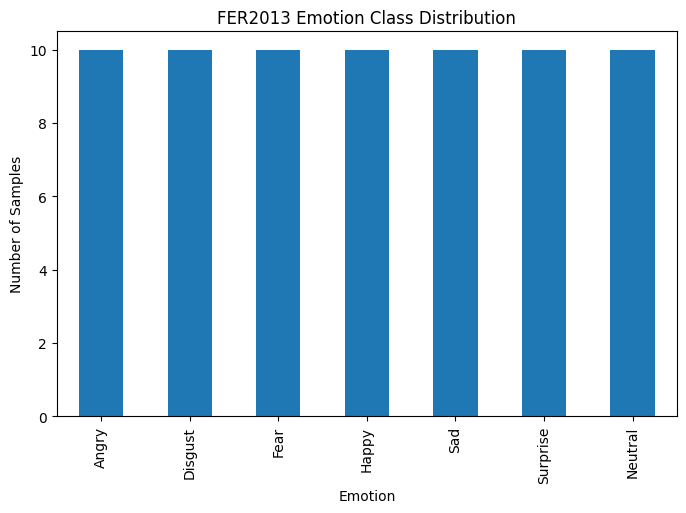

In [14]:
import matplotlib.pyplot as plt

emotion_count.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "FER2013 Emotion Class Distribution"
)

plt.xlabel("Emotion")

plt.ylabel("Number of Samples")

plt.show()

3. Write a Python function that takes a single pixel string from the FER2013 dataset, converts it to a numpy array, and reshapes it into the correct image dimensions. Display the shape to confirm it matches the expected size.


In [15]:
import numpy as np

In [ ]:
def pixel_string_to_image(pixel_string):
    pixels = np.array(
        pixel_string.split(),
        dtype=np.uint8
    )
    image = pixels.reshape(48, 48)

    return image

In [ ]:
sample_pixels = " ".join(
    map(
        str,
        np.random.randint(
            0,
            256,
            2304
        )
    )
)

image_array = pixel_string_to_image(
    sample_pixels
)

print("Image Shape:", image_array.shape)

Image Shape: (48, 48)


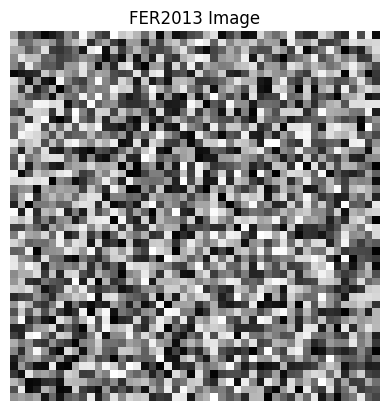

In [18]:
import matplotlib.pyplot as plt

plt.imshow(
    image_array,
    cmap="gray"
)

plt.title("FER2013 Image")

plt.axis("off")

plt.show()

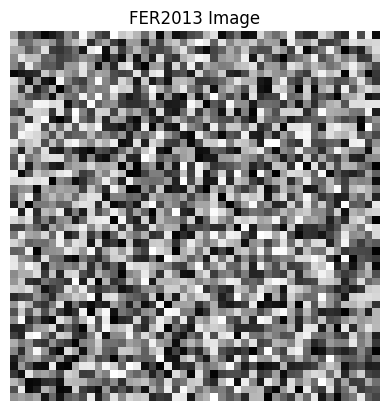

In [19]:
import matplotlib.pyplot as plt

plt.imshow(
    image_array,
    cmap="gray"
)

plt.title("FER2013 Image")

plt.axis("off")

plt.show()

In [21]:
import pandas as pd

df = pd.read_csv("fer2013_small.csv")

pixel_data = df["pixels"][0]

image = pixel_string_to_image(pixel_data)

print(image.shape)

(48, 48)


4. Implement a preprocessing step that normalizes the pixel values of all images in the FER2013 dataset to the range [0, 1] and splits the data into train, validation, and test sets using an 80-10-10 split.<br><br><em><strong>Constraint:</strong> Use sklearn's train_test_split for both splits.</em>


In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("fer2013_small.csv")

df.head()

,emotion,pixels,Usage
0,0,9 255 109 182 156 200 177 55 211 146 120 48 21...,Training
1,0,129 122 206 1 142 182 179 116 169 201 64 187 1...,Training
2,0,220 138 128 139 118 205 19 21 3 29 80 165 135 ...,Training
3,0,97 142 64 41 71 66 175 16 118 88 44 142 20 125...,Training
4,0,10 91 133 243 179 172 150 227 64 241 54 212 74...,Training


In [24]:
def convert_pixels(pixel_string):

    image = np.array(
        pixel_string.split(),
        dtype="float32"
    )

    image = image.reshape(
        48, 48, 1
    )

    return image

In [ ]:
X = np.array(
    [
        convert_pixels(pixel)
        for pixel in df["pixels"]
    ]
)
y = df["emotion"].values


print("Image data shape:", X.shape)
print("Labels shape:", y.shape)

Image data shape: (70, 48, 48, 1)
Labels shape: (70,)


In [ ]:
X = X / 255.0

print("Minimum pixel value:", X.min())

print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [27]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print(X_train.shape)
print(X_temp.shape)

(56, 48, 48, 1)
(14, 48, 48, 1)


In [28]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)


print("Training Data:", X_train.shape)
print("Validation Data:", X_val.shape)
print("Testing Data:", X_test.shape)

Training Data: (56, 48, 48, 1)
Validation Data: (7, 48, 48, 1)
Testing Data: (7, 48, 48, 1)


5. Suppose you notice that the 'disgust' class in the FER2013 dataset has very few samples. Propose one method to address this imbalance and write a short Python code snippet to demonstrate how you would apply it on the training set.

In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

In [ ]:
augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
X_train  
y_train   

array([5, 5, 0, 5, 4, 2, 3, 1, 0, 1, 2, 6, 3, 5, 6, 2, 0, 2, 6, 1, 6, 3,
       4, 5, 1, 1, 2, 4, 3, 3, 2, 4, 6, 1, 3, 6, 6, 1, 4, 3, 2, 3, 6, 5,
       0, 0, 0, 4, 4, 2, 1, 4, 5, 0, 5, 0])

In [ ]:
disgust_images = X_train[y_train == 1]


print(
    "Original disgust samples:",
    len(disgust_images)
)

Original disgust samples: 8


In [34]:
augmented_images = []

for image in disgust_images:

    image = np.expand_dims(
        image,
        axis=0
    )

    generator = augmentor.flow(
        image,
        batch_size=1
    )

    new_image = next(generator)[0]

    augmented_images.append(
        new_image
    )


augmented_images = np.array(
    augmented_images
)


print(
    "Generated samples:",
    augmented_images.shape
)

Generated samples: (8, 48, 48, 1)


In [ ]:
X_train_balanced = np.concatenate(
    [
        X_train,
        augmented_images
    ]
)


y_train_balanced = np.concatenate(
    [
        y_train,
        np.ones(len(augmented_images))
    ]
)


print(
    "New training size:",
    X_train_balanced.shape
)

New training size: (64, 48, 48, 1)
